In [1]:
import rioxarray
import matplotlib.pyplot 
import numpy
import skimage

In [2]:
Asheville = rioxarray.open_rasterio(r"C:\Users\liamt\Documents\School Stuff\AES 408\Hw 4\m_3508228_nw_17_060_20220923.tif")

In [3]:
Asheville

<xarray.DataArray (band: 4, y: 12380, x: 10300)> Size: 510MB
[510056000 values with dtype=uint8]
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 99kB 3.944e+06 3.944e+06 ... 3.936e+06 3.936e+06
  * x            (x) float64 82kB 3.525e+05 3.525e+05 ... 3.587e+05 3.587e+05
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0

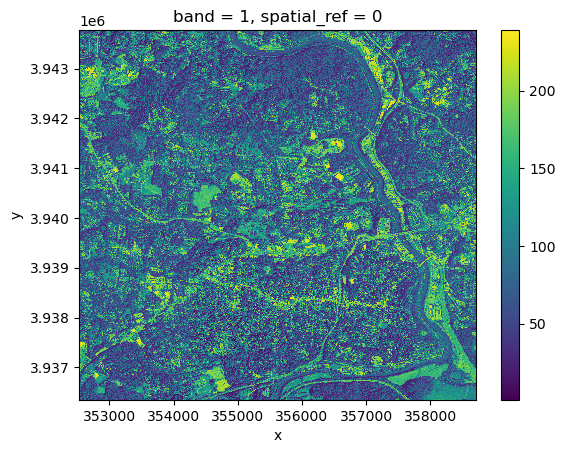

In [4]:
Asheville[0].plot()

In [5]:
RGB_Asheville = Asheville[:3].values.transpose(1, 2, 0)

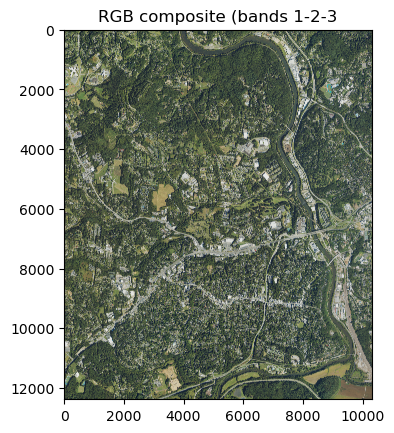

In [6]:
matplotlib.pyplot.imshow(RGB_Asheville)
matplotlib.pyplot.title("RGB composite (bands 1-2-3")
matplotlib.pyplot.show()

In [7]:
red = Asheville[2].astype(float)
NIR = Asheville[3].astype(float)
NDVI = (NIR - red) / (NIR + red + 1e-6)

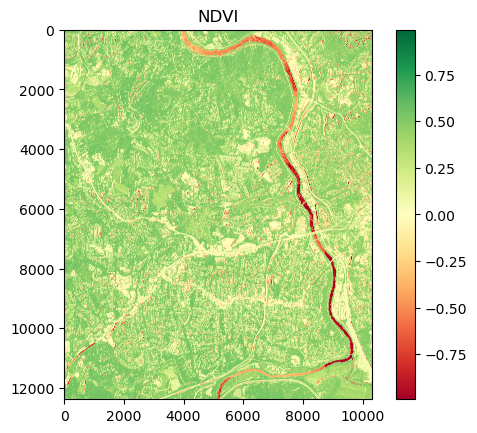

In [8]:
matplotlib.pyplot.imshow(NDVI, "RdYlGn")
matplotlib.pyplot.colorbar()
matplotlib.pyplot.title("NDVI")
matplotlib.pyplot.show()

In [14]:
from skimage.morphology import remove_small_objects, closing, square
from skimage.measure import label, regionprops
from skimage.color import label2rgb
from matplotlib.patches import Rectangle

In [15]:
Possible_buildings = (NDVI > -0.2) & (NDVI < 0.2)
Possible_buildings_numpy = Possible_buildings.values.astype(bool) #Converting it from xarray to numpy to use skimage

C:\Users\liamt\AppData\Local\Temp\ipykernel_23944\1923281602.py:1: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  Clean_buildings = remove_small_objects(Possible_buildings_numpy, min_size = 50)


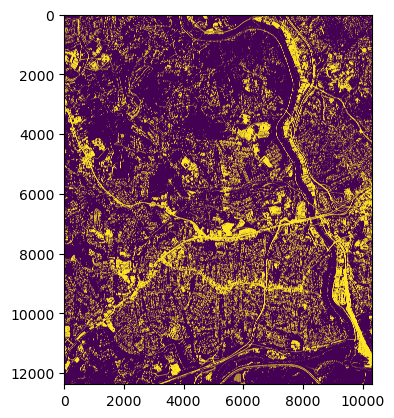

In [16]:
Clean_buildings = remove_small_objects(Possible_buildings_numpy, min_size = 50)
#Clean_buildings = closing(Possible_buildings_numpy, square(3))

matplotlib.pyplot.imshow(Clean_buildings)
matplotlib.pyplot.show()


In [17]:
labeled_buildings = label(Clean_buildings)
print(f"number of possible buildings: {labeled_buildings.max()}")

number of possible buildings: 18333


In [24]:
building_regions = regionprops(labeled_buildings)

In [32]:
 #Sort regions by area, largest first
#sorted_buildings = sorted(building_regions, key = lambda r: r.area, reverse = True)
#areas = [r.area for r in sorted_buildings]

#print(f"{'ID':<5}{'AREA':<10}")
#print("-" * 20)
 #Loop through building regions
#for i, area in enumerate(areas, start=1):
    #print(f"{i:<5}{area:<10}")

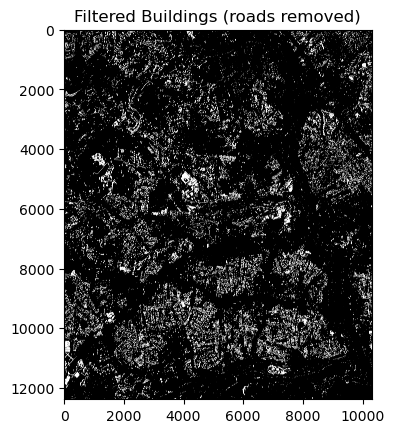

In [48]:
# Get properties as arrays instead of looping because looping was taking to long
areas        = numpy.array([r.area for r in building_regions])
eccentricities = numpy.array([r.eccentricity for r in building_regions])
labels       = numpy.array([r.label for r in building_regions])

bboxes = numpy.array([r.bbox for r in building_regions])
heights = bboxes[:, 2] - bboxes[:, 0]
widths  = bboxes[:, 3] - bboxes[:, 1]
aspect_ratios = numpy.maximum(heights, widths) / (numpy.minimum(heights, widths) + 1e-5)

# Apply all filters at once
keep = (
    (areas > 50)          &
    (areas < 150000)      &
    (eccentricities < 0.96) &
    (aspect_ratios < 6.0))

# Build mask using only kept labels
kept_labels = labels[keep]
buildings_filtered = numpy.isin(labeled_buildings, kept_labels).astype(numpy.uint8)

matplotlib.pyplot.imshow(buildings_filtered, cmap='gray')
matplotlib.pyplot.title("Filtered Buildings (roads removed)")
matplotlib.pyplot.show()

In [49]:
#import pandas

In [45]:
#test to see which regions are getting left out and what I might need to do to the code above to add them
#diagnostics = pandas.DataFrame({
    #"label": labels,
    #"area": areas,
    #"eccentricity": eccentricities,
    #"aspect_ratio": aspect_ratios,
    #"kept": keep})
#rejected = diagnostics[~diagnostics["kept"]].sort_values("area", ascending = False)
#print("Top 20 rejected regions:")
#print(rejected.head(20))